### Pytorch computation graph and autograd

In [50]:
import torch

# 1. Create a tensor (like numpy array)
x = torch.tensor([1.0, 2.0, 3.0])
print(x)

# 2. Tensor operations
y = x + 10
print(y)

# 3. Matrix multiplication
A = torch.randn(3, 4)  # Random 3x4 matrix
B = torch.randn(4, 5)  # Random 4x5 matrix
C = torch.matmul(A, B)  # Or: A @ B
print(C.shape)  # Should be (3, 5)

print(torch.zeros((2, 3)).shape)

tensor([1., 2., 3.])
tensor([11., 12., 13.])
torch.Size([3, 5])
torch.Size([2, 3])


In [51]:
b = torch.zeros((10,))
b.shape

torch.Size([10])

In [52]:
# Example 1: Simple computation
x = torch.tensor([5.0], requires_grad=True)
y = x ** 2
print(y)  # tensor([25.], grad_fn=<PowBackward0>)

y.backward()  # Compute ∂y/∂x
print(x.grad)  # tensor([10.]) because ∂(x²)/∂x = 2x = 10


tensor([25.], grad_fn=<PowBackward0>)
tensor([10.])


In [53]:
# Leaf: Created directly, not from operations
x = torch.tensor([5.0], requires_grad=True)
W = nn.Parameter(torch.randn(3, 2))

print(x.is_leaf)  # True
print(W.is_leaf)  # True

# After backward: x.grad and W.grad are filled! ✅

# Non-leaf: Created from operations
y = x ** 2
z = y + 10

print(y.is_leaf)  # False
print(z.is_leaf)  # False

z.backward()

print(x.grad)  # ✅ Filled! (x is a leaf)
print(y.grad)  # ❌ None! (y is not a leaf)
print(z.grad)  # ❌ None! (z is not a leaf)

True
True
False
False
tensor([10.])
None
None


/var/folders/lb/pzr9x7ld4yd0t916649wxxrw0000gn/T/ipykernel_54600/1891792727.py:20: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  print(y.grad)  # ❌ None! (y is not a leaf)
/var/folders/lb/pzr9x7ld4yd0t916649wxxrw0000gn/T/ipykernel_54600/1891792727.py:21: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad

### Logistic Regression with Pytorch

In [54]:
import torch.nn as nn

class SimpleLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()  # ALWAYS call this first!
        
        # Create a learnable weight matrix (use nn.Parameter)
        self.W = nn.Parameter(torch.randn(output_size, input_size))
        
        # Create a learnable bias vector (use nn.Parameter)
        self.b = nn.Parameter(torch.zeros(output_size))
        
    def forward(self, x):
        # x shape is (batch_size, input_size)
        # W shape is (output_size, input_size)
        # b shape is (output_size,) - broadcastable to (batch_size, output_size)
        return torch.sigmoid(x @ self.W.T + self.b)

layer = SimpleLayer(3, 2)
print("W", layer.W)
print("b", layer.b)

layer.forward(
    torch.tensor(
        [
            [1.0, 2.0, 3.0],
            [4.0, 5.0, 6.0],
            [7.0, 8.0, 9.0],
            [10.0, 11.0, 12.0],
        ]
    )
)

W Parameter containing:
tensor([[-1.2315, -1.0470, -1.7461],
        [-0.3742, -0.4117, -0.8997]], requires_grad=True)
b Parameter containing:
tensor([0., 0.], requires_grad=True)


tensor([[1.9088e-04, 1.9901e-02],
        [1.0897e-09, 1.2921e-04],
        [6.2200e-15, 8.2247e-07],
        [3.5503e-20, 5.2345e-09]], grad_fn=<SigmoidBackward0>)

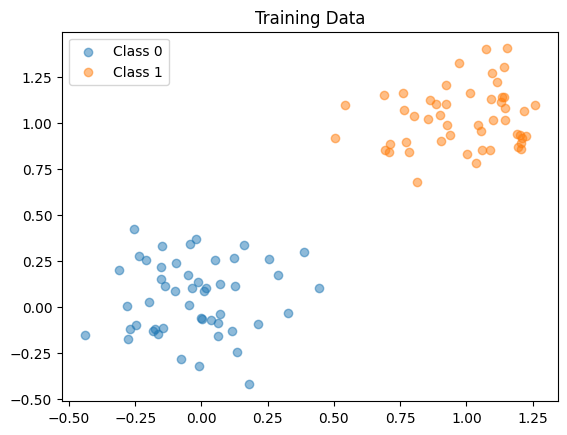

X shape: torch.Size([100, 2])
y shape: torch.Size([100])


In [57]:
import matplotlib.pyplot as plt

# 1. Create toy dataset (simple 2D classification)
# Class 0: points near (0, 0)
# Class 1: points near (1, 1)
torch.manual_seed(42)

X_class0 = torch.randn(50, 2) * 0.2 + torch.tensor([0.0, 0.0])  # 50 points near origin
X_class1 = torch.randn(50, 2) * 0.2 + torch.tensor([1.0, 1.0])  # 50 points near (1,1)

X = torch.cat([X_class0, X_class1], dim=0)  # (100, 2)
y = torch.cat([torch.zeros(50), torch.ones(50)])  # (100,) labels

# Visualize the data
plt.scatter(X[:50, 0], X[:50, 1], label='Class 0', alpha=0.5)
plt.scatter(X[50:, 0], X[50:, 1], label='Class 1', alpha=0.5)
plt.legend()
plt.title('Training Data')
plt.show()

print(f"X shape: {X.shape}")  # (100, 2) - 100 samples, 2 features
print(f"y shape: {y.shape}")  # (100,) - 100 labels

In [58]:
model = SimpleLayer(input_size=2, output_size=1)
print("Initial weights:", model.W)
print("Initial bias:", model.b)

# Binary Cross Entropy Loss (standard for logistic regression)
loss_fn = nn.BCELoss()  # BCE = Binary Cross Entropy

# Optimizer updates the weights after backprop
# learning_rate controls how big the steps are
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# What are model.parameters()?
print("Learnable parameters:", list(model.parameters()))
# These are your W and b!

Initial weights: Parameter containing:
tensor([[ 0.3932, -0.2148]], requires_grad=True)
Initial bias: Parameter containing:
tensor([0.], requires_grad=True)
Learnable parameters: [Parameter containing:
tensor([[ 0.3932, -0.2148]], requires_grad=True), Parameter containing:
tensor([0.], requires_grad=True)]


Epoch 10/100, Loss: 0.5712
Epoch 20/100, Loss: 0.5102
Epoch 30/100, Loss: 0.4632
Epoch 40/100, Loss: 0.4247
Epoch 50/100, Loss: 0.3922
Epoch 60/100, Loss: 0.3641
Epoch 70/100, Loss: 0.3396
Epoch 80/100, Loss: 0.3180
Epoch 90/100, Loss: 0.2989
Epoch 100/100, Loss: 0.2818


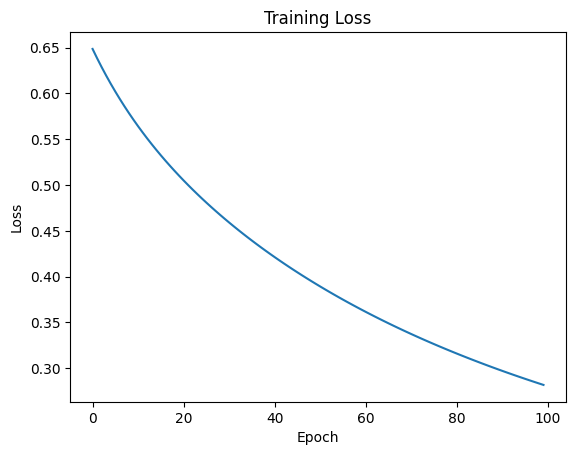

In [59]:
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    # 1. FORWARD PASS
    predictions = model(X)  # Calls forward() automatically
    predictions = predictions.squeeze()  # (100, 1) → (100,)
    
    # 2. COMPUTE LOSS
    loss = loss_fn(predictions, y)
    
    # 3. BACKWARD PASS (compute gradients)
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute new gradients (autograd magic!)
    
    # 4. UPDATE WEIGHTS
    optimizer.step()       # Update W and b using gradients
    
    # Track loss
    losses.append(loss.item())
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Accuracy: 99.00%


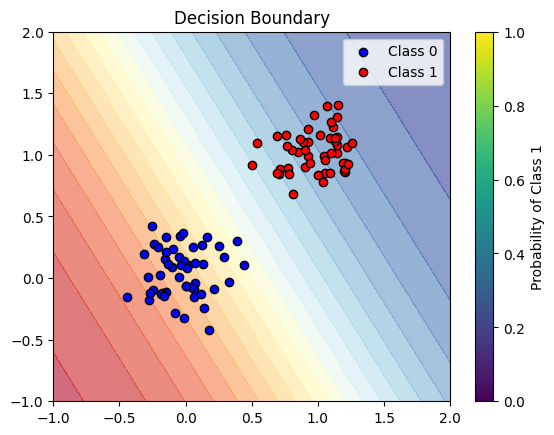

In [60]:
# Evaluate on the training data
with torch.no_grad():  # Don't track gradients during evaluation
    predictions = model(X).squeeze()
    predicted_classes = (predictions > 0.5).float()
    accuracy = (predicted_classes == y).float().mean()
    print(f"Accuracy: {accuracy.item():.2%}")

# Visualize the decision boundary
import numpy as np

# Create a grid
xx, yy = np.meshgrid(np.linspace(-1, 2, 100), np.linspace(-1, 2, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid).squeeze().numpy()
    Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.scatter(X[:50, 0], X[:50, 1], c='blue', label='Class 0', edgecolors='k')
plt.scatter(X[50:, 0], X[50:, 1], c='red', label='Class 1', edgecolors='k')
plt.colorbar(label='Probability of Class 1')
plt.legend()
plt.title('Decision Boundary')
plt.show()

### Logistic Regression with Manual Pytorch

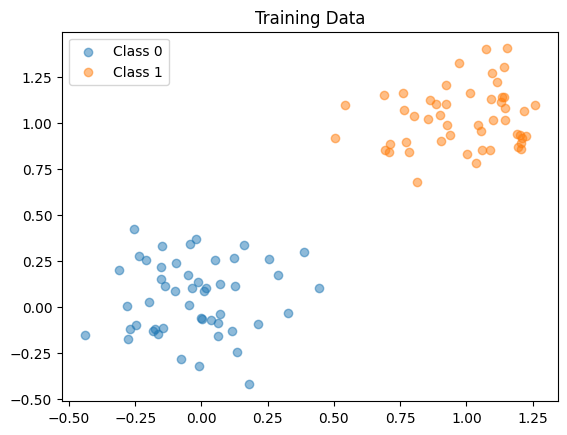

X shape: torch.Size([100, 2])
y shape: torch.Size([100])


In [62]:
import matplotlib.pyplot as plt

# 1. Create toy dataset (simple 2D classification)
# Class 0: points near (0, 0)
# Class 1: points near (1, 1)
torch.manual_seed(42)

X_class0 = torch.randn(50, 2) * 0.2 + torch.tensor([0.0, 0.0])  # 50 points near origin
X_class1 = torch.randn(50, 2) * 0.2 + torch.tensor([1.0, 1.0])  # 50 points near (1,1)

X = torch.cat([X_class0, X_class1], dim=0)  # (100, 2)
y = torch.cat([torch.zeros(50), torch.ones(50)])  # (100,) labels

# Visualize the data
plt.scatter(X[:50, 0], X[:50, 1], label='Class 0', alpha=0.5)
plt.scatter(X[50:, 0], X[50:, 1], label='Class 1', alpha=0.5)
plt.legend()
plt.title('Training Data')
plt.show()

print(f"X shape: {X.shape}")  # (100, 2) - 100 samples, 2 features
print(f"y shape: {y.shape}")  # (100,) - 100 labels

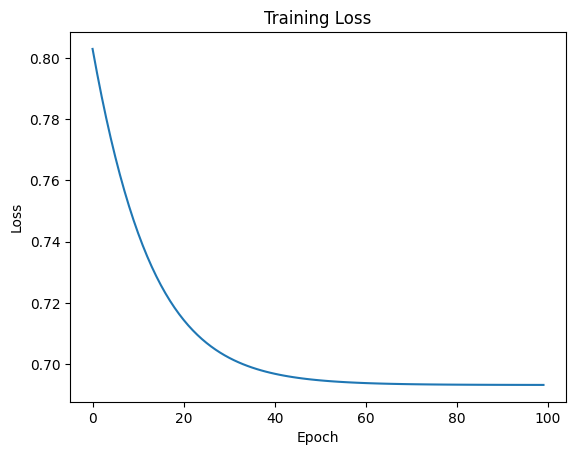

In [64]:
import torch

# 1. Define parameters manually
W = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

losses = []

# 2. Training loop
for epoch in range(100):
    # Forward (computational graph)
    pred = X @ W + b
    pred = torch.sigmoid(pred)
    
    # Loss (just another operation)
    loss = -(y * torch.log(pred) + (1-y) * torch.log(1-pred)).mean()
    losses.append(loss.item())
    
    # Backward (autograd)
    loss.backward()
    
    # Update (manual gradient descent)
    with torch.no_grad():
        W -= 0.1 * W.grad
        b -= 0.1 * b.grad
        W.grad.zero_()
        b.grad.zero_()

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()